In [1]:
import pandas as pd
import numpy as np
import ast
import re
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import log_loss, roc_auc_score, f1_score, brier_score_loss
import matplotlib.pyplot as plt

In [2]:
students = pd.read_csv("../Dataset/student.csv")
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17340 entries, 0 to 17339
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   student_id                           17340 non-null  object 
 1   quiz_id                              17340 non-null  int64  
 2   session_id                           17340 non-null  object 
 3   question_id                          17340 non-null  int64  
 4   question_in_quiz                     17340 non-null  int64  
 5   difficulty                           17340 non-null  object 
 6   topic                                17340 non-null  object 
 7   response_time                        17340 non-null  float64
 8   accuracy_so_far                      17340 non-null  float64
 9   number_of_questions_answered_so_far  17340 non-null  int64  
 10  accuracy_easy_so_far                 17340 non-null  float64
 11  accuracy_medium_so_far      

In [3]:
questions = pd.read_csv("../Dataset/questions.csv")
questions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   question_id        150 non-null    int64  
 1   question_text      150 non-null    object 
 2   correct_answer     150 non-null    object 
 3   difficulty         150 non-null    object 
 4   num_words          150 non-null    int64  
 5   qstn_complexity    150 non-null    float64
 6   options_cleaned    150 non-null    object 
 7   num_options        150 non-null    int64  
 8   avg_option_length  150 non-null    float64
 9   embedding          150 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 11.8+ KB


In [4]:
# Merge students with questions on question_id
df = pd.merge(students, questions, on='question_id', how='inner')
df = df.drop(columns=['student_id', 'question_id', 'quiz_id', 'question_text', 'difficulty_x', 'options_cleaned', 'correct_answer', 'topic', 'embedding', 'response_time', 'last_1_correctness', 'last_2_correctness', 'last_3_correctness', 'question_in_quiz'])

df = df.rename(columns={'difficulty_y': 'difficulty'})
difficulty_mapping = {'easy': 0, 'medium': 1, 'hard': 2}
df['difficulty'] = df['difficulty'].map(difficulty_mapping)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17340 entries, 0 to 17339
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   session_id                           17340 non-null  object 
 1   accuracy_so_far                      17340 non-null  float64
 2   number_of_questions_answered_so_far  17340 non-null  int64  
 3   accuracy_easy_so_far                 17340 non-null  float64
 4   accuracy_medium_so_far               17340 non-null  float64
 5   accuracy_hard_so_far                 17340 non-null  float64
 6   average_response_time_so_far         17340 non-null  float64
 7   correct                              17340 non-null  int64  
 8   difficulty                           17340 non-null  int64  
 9   num_words                            17340 non-null  int64  
 10  qstn_complexity                      17340 non-null  float64
 11  num_options                 

In [5]:
#Group split (by session_id)
gss = GroupShuffleSplit(test_size=0.3, n_splits=1, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['session_id']))

train_df = df.iloc[train_idx].reset_index(drop=True)
test_df  = df.iloc[test_idx].reset_index(drop=True)

In [6]:
# Separate features / target
X_train_full = train_df.drop(columns=['correct', 'session_id'])
y_train_full = train_df['correct']

X_test = test_df.drop(columns=['correct', 'session_id'])
y_test = test_df['correct']

# Initialize labeled / unlabeled pools
X_L, X_U, y_L, y_U = train_test_split(
    X_train_full, y_train_full,
    test_size=0.9,
    random_state=42,
    stratify=y_train_full
)

In [7]:
model_factories = {
    "xgboost": lambda: XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),
    "random_forest": lambda: RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        n_jobs=-1,
        random_state=42
    ),
    "logistic_regression": lambda: LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        random_state=42
    ),
    "naive_bayes": lambda: GaussianNB(),
    "gradient_boosting": lambda: GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
}


def entropy(p):
    return -(p*np.log(p + 1e-10) + (1-p)*np.log(1-p + 1e-10))

In [8]:
model_results = []
histories = {}

best_model = None
best_history = None
best_model_name = None
best_logloss = float("inf")

patience = 5
step_size = 0.05
total_size = len(X_train_full)

# Reset pools for each model to keep comparisons fair
X_L_init = X_L.copy()
X_U_init = X_U.copy()
y_L_init = y_L.copy()
y_U_init = y_U.copy()

for model_name, model_factory in model_factories.items():
    model = model_factory()

    best_loss = float("inf")
    no_improve = 0
    history = []

    X_L = X_L_init.copy()
    X_U = X_U_init.copy()
    y_L = y_L_init.copy()
    y_U = y_U_init.copy()

    while True:
        # 1. Train
        model.fit(X_L, y_L)

        # 2. Predict on test
        probs_test = model.predict_proba(X_test)[:, 1]
        preds_test = (probs_test >= 0.5).astype(int)

        # 3. Metrics
        loss = log_loss(y_test, probs_test)
        auc = roc_auc_score(y_test, probs_test)
        f1 = f1_score(y_test, preds_test)
        brier = brier_score_loss(y_test, probs_test)

        # 4. Progress tracking
        labeled_ratio = len(X_L) / total_size

        history.append({
            "labeled_size": len(X_L),
            "labeled_ratio": labeled_ratio,
            "logloss": loss,
            "auc": auc,
            "f1": f1,
            "brier": brier
        })

        print(
            f"[{model_name}] Labeled: {len(X_L)} ({labeled_ratio:.2%}) | "
            f"LogLoss: {loss:.4f} | AUC: {auc:.4f}"
        )

        # 5. Stopping criterion (LogLoss plateau)
        if best_loss - loss > 0.01:
            best_loss = loss
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience or len(X_U) == 0:
            break

        # 6. Uncertainty sampling (entropy)
        probs_unlabeled = model.predict_proba(X_U)[:, 1]
        ent = entropy(probs_unlabeled)

        k = max(1, int(step_size * len(X_U)))
        idx = np.argsort(ent)[-k:]

        # 7. Select samples
        X_selected = X_U.iloc[idx]
        y_selected = y_U.iloc[idx]

        # 8. Update pools
        X_L = pd.concat([X_L, X_selected])
        y_L = pd.concat([y_L, y_selected])

        X_U = X_U.drop(X_U.index[idx])
        y_U = y_U.drop(y_U.index[idx])

    model_best_logloss = min(h["logloss"] for h in history)
    model_results.append({
        "model": model_name,
        "best_logloss": model_best_logloss,
        "final_logloss": history[-1]["logloss"],
        "final_labeled_ratio": history[-1]["labeled_ratio"]
    })
    histories[model_name] = history

    if model_best_logloss < best_logloss:
        best_logloss = model_best_logloss
        best_model = model
        best_history = history
        best_model_name = model_name

results_df = pd.DataFrame(model_results).sort_values("best_logloss")
print("Best model:", best_model_name, "| best logloss:", best_logloss)
print(results_df)

model = best_model
history = best_history

[xgboost] Labeled: 1212 (10.00%) | LogLoss: 0.4053 | AUC: 0.8335
[xgboost] Labeled: 1757 (14.50%) | LogLoss: 0.3972 | AUC: 0.8409
[xgboost] Labeled: 2275 (18.77%) | LogLoss: 0.3926 | AUC: 0.8436
[xgboost] Labeled: 2767 (22.83%) | LogLoss: 0.3887 | AUC: 0.8463
[xgboost] Labeled: 3234 (26.68%) | LogLoss: 0.3868 | AUC: 0.8451
[xgboost] Labeled: 3678 (30.35%) | LogLoss: 0.3841 | AUC: 0.8498
[xgboost] Labeled: 4100 (33.83%) | LogLoss: 0.3818 | AUC: 0.8509
[xgboost] Labeled: 4501 (37.14%) | LogLoss: 0.3794 | AUC: 0.8560
[xgboost] Labeled: 4881 (40.27%) | LogLoss: 0.3777 | AUC: 0.8568
[xgboost] Labeled: 5242 (43.25%) | LogLoss: 0.3761 | AUC: 0.8613
[xgboost] Labeled: 5585 (46.08%) | LogLoss: 0.3725 | AUC: 0.8648
[xgboost] Labeled: 5911 (48.77%) | LogLoss: 0.3726 | AUC: 0.8657
[random_forest] Labeled: 1212 (10.00%) | LogLoss: 0.3937 | AUC: 0.8395
[random_forest] Labeled: 1757 (14.50%) | LogLoss: 0.3890 | AUC: 0.8455
[random_forest] Labeled: 2275 (18.77%) | LogLoss: 0.3880 | AUC: 0.8465
[random

c:\Users\Nacer\anaconda3\envs\DM_ENV\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[logistic_regression] Labeled: 1212 (10.00%) | LogLoss: 0.4049 | AUC: 0.8263


c:\Users\Nacer\anaconda3\envs\DM_ENV\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[logistic_regression] Labeled: 1757 (14.50%) | LogLoss: 0.4075 | AUC: 0.8191


...

[logistic_regression] Labeled: 2767 (22.83%) | LogLoss: 0.4018 | AUC: 0.8125


c:\Users\Nacer\anaconda3\envs\DM_ENV\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[logistic_regression] Labeled: 3234 (26.68%) | LogLoss: 0.4016 | AUC: 0.8143


c:\Users\Nacer\anaconda3\envs\DM_ENV\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[logistic_regression] Labeled: 3678 (30.35%) | LogLoss: 0.4025 | AUC: 0.8142
[naive_bayes] Labeled: 1212 (10.00%) | LogLoss: 0.5536 | AUC: 0.8142
[naive_bayes] Labeled: 1757 (14.50%) | LogLoss: 0.4829 | AUC: 0.7857
[naive_bayes] Labeled: 2275 (18.77%) | LogLoss: 0.4561 | AUC: 0.7941
[naive_bayes] Labeled: 2767 (22.83%) | LogLoss: 0.4490 | AUC: 0.7864
[naive_bayes] Labeled: 3234 (26.68%) | LogLoss: 0.4601 | AUC: 0.7790
[naive_bayes] Labeled: 3678 (30.35%) | LogLoss: 0.4219 | AUC: 0.7956
[naive_bayes] Labeled: 4100 (33.83%) | LogLoss: 0.4242 | AUC: 0.8003
[naive_bayes] Labeled: 4501 (37.14%) | LogLoss: 0.4689 | AUC: 0.7891
[naive_bayes] Labeled: 4881 (40.27%) | LogLoss: 0.4673 | AUC: 0.7880
[naive_bayes] Labeled: 5242 (43.25%) | LogLoss: 0.4553 | AUC: 0.7890
[naive_bayes] Labeled: 5585 (46.08%) | LogLoss: 0.4509 | AUC: 0.7939
[gradient_boosting] Labeled: 1212 (10.00%) | LogLoss: 0.3991 | AUC: 0.8381
[gradient_boosting] Labeled: 1757 (14.50%) | LogLoss: 0.3952 | AUC: 0.8364
[gradient_boos

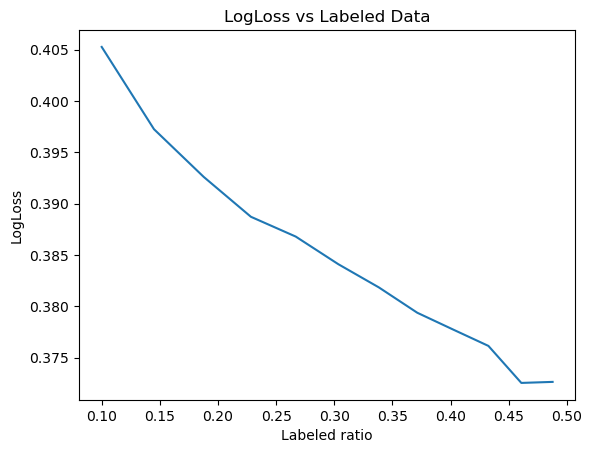

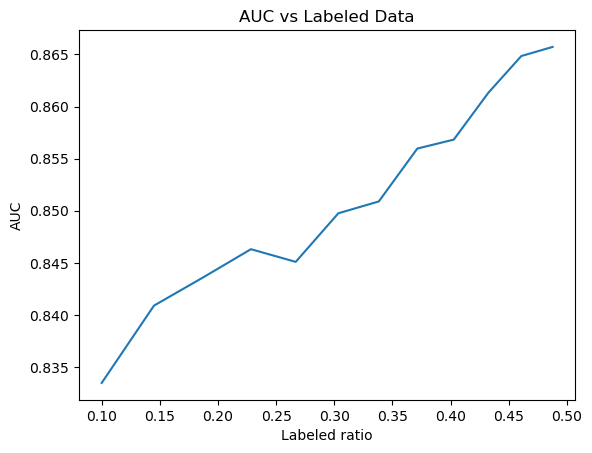

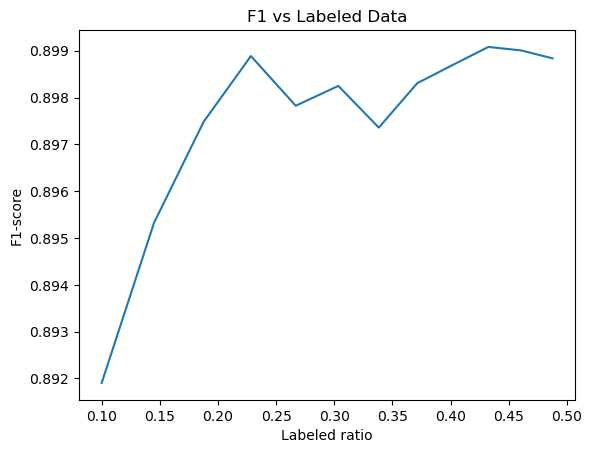

In [9]:
history_df = pd.DataFrame(history)

# LogLoss
plt.figure()
plt.plot(history_df["labeled_ratio"], history_df["logloss"])
plt.xlabel("Labeled ratio")
plt.ylabel("LogLoss")
plt.title("LogLoss vs Labeled Data")
plt.show()

# AUC
plt.figure()
plt.plot(history_df["labeled_ratio"], history_df["auc"])
plt.xlabel("Labeled ratio")
plt.ylabel("AUC")
plt.title("AUC vs Labeled Data")
plt.show()

# F1
plt.figure()
plt.plot(history_df["labeled_ratio"], history_df["f1"])
plt.xlabel("Labeled ratio")
plt.ylabel("F1-score")
plt.title("F1 vs Labeled Data")
plt.show()

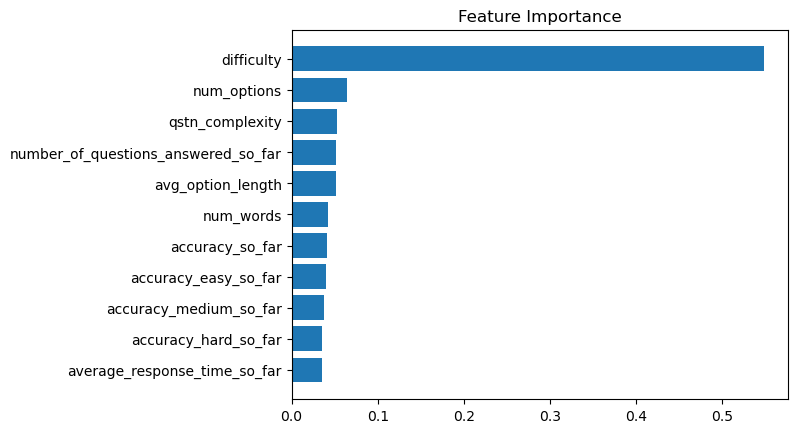

,feature,importance
6,difficulty,0.548696
9,num_options,0.064686
8,qstn_complexity,0.052699
1,number_of_questions_answered_so_far,0.051658
10,avg_option_length,0.051498
7,num_words,0.042420
0,accuracy_so_far,0.040544
2,accuracy_easy_so_far,0.040499
3,accuracy_medium_so_far,0.037145
4,accuracy_hard_so_far,0.035235


In [10]:
# feature importance
importances = model.feature_importances_
feature_names = X_train_full.columns

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

# plot top 20 features (no embeddings)
top = fi_df.head(20)

plt.figure()
plt.barh(top["feature"][::-1], top["importance"][::-1])
plt.title("Feature Importance")
plt.show()

# full table
fi_df

In [11]:
# Evaluate the final model on the test set
print("Evaluating the final model on the test set:")
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Log Loss:", log_loss(y_test, y_prob))
print("AUC Score:", roc_auc_score(y_test, y_prob))
print("Brier Score:", brier_score_loss(y_test, y_prob))


Evaluating the final model on the test set:
Log Loss: 0.3726321252395159
AUC Score: 0.8657233802161338
Brier Score: 0.11465199760822176


- Log Loss = 0.3726 → good probability quality, low prediction error, model is confident and mostly correct
- AUC = 0.8657 → strong ranking ability, model can clearly separate correct vs incorrect answers
- Brier Score = 0.1147 → good calibration, predicted probabilities are reasonably close to real outcomes

In [13]:
import joblib
joblib.dump(model, "../models/xgboost.pkl")

['../models/xgboost.pkl']